# Resolucao do sudoku com metaheuristicas

## Instalacao das bibliotecas necessarias

In [1]:
#@title Instalar lib
%pip install py-sudoku
%pip install numpy
%pip install matplotlib
%pip install pillow
%pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: pillow in c:\users\lademir júnior\appdata\local\programs\python\python39\lib\site-packages (10.0.0)



You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: opencv-python in c:\users\lademir júnior\appdata\local\programs\python\python39\lib\site-packages (4.8.0.74)



You should consider upgrading via the 'c:\Users\Lademir Júnior\AppData\Local\Programs\Python\Python39\python.exe -m pip install --upgrade pip' command.


## Funcoes auxiliares

* Funcao de Leitura de arquivos

In [ ]:
#@title Funcoes auxiliares
import numpy as np
from typing import List
import math

def read_file(caminho, size=3) -> List[List[int]]:
  with open(caminho, 'r') as arquivo:
    linhas = arquivo.readlines()  # Ler todas as linhas do arquivo

  puzzle: List[List[int]] = []

  # Processar cada linha e criar a matriz
  for linha in linhas:
      valores_str = linha.strip()[1:-1].split(", ")  # Remover os colchetes e separar os valores pelo separador (', ')
      numeros = []

      for val in valores_str:
        if val == 'None':
          numeros.append(None)
          pass
        else:
          numeros.append(int(val))
          pass

      puzzle.append(numeros)

  # puzzle = Sudoku(size, size, board=puzzle)

  return puzzle





## Geracao de instacias de sudoku

Utilizando biblioteca py-sudoku para geracao de instancias

https://github.com/jeffsieu/py-sudoku

* Para gerar quebra-cabecas diferentes, necessario passar seeds diferentes para cada instancia, para isso, utilizo a lib random para gerar um inteiro aleatorio.




In [ ]:
from sudoku import Sudoku
import random

puzzle = Sudoku(3, seed=random.randint(1, 100)).difficulty(0.9)

print(puzzle.board)

[[None, None, None, None, None, None, None, None, None], [None, None, None, None, None, None, 3, None, 9], [None, None, None, None, 9, None, None, None, None], [None, 7, None, None, None, None, None, None, None], [None, None, None, None, None, 2, None, None, None], [None, None, None, None, None, None, None, 5, None], [None, 5, 3, None, None, None, None, None, None], [None, None, None, None, None, None, None, None, None], [None, None, None, None, None, None, None, None, 1]]


### Criacao das instancias

* 300 faceis
* 300 medias
* 300 dificeis

Obs:

In [3]:
#@title Criar instancias
import random
from sudoku import Sudoku
import os

folder_path = './instancias'

easy = 1 - 0.43
medium = 1 - 0.37
hard = 1 - 0.20

def make_easy_instances():
  for i in range(300):
    os.makedirs(folder_path + '/facil (0.3)', exist_ok=True)
    file_path = os.path.join(folder_path + '/facil (0.3)', f'instancia{i}.txt')
    with open(file_path, 'w') as f:
      puzzle = Sudoku(3, seed=i).difficulty(easy)
      for row in puzzle.board:
        f.write(str(row) + '\n')
    # print('[ * ] Finalizou a criacao das instancias faceis')

    # os.makedirs(folder_path + '/solution' + '/facil', exist_ok=True)
    # file_path_solved = os.path.join(folder_path + '/solution' + '/facil', f'instancia{i}.txt')
    # with open(file_path_solved, 'w') as f:
    #   for row in puzzle.solve().board:
    #     f.write(str(row) + '\n')

  print(f'[ * ] Finalizou criacao de instancias faceis')

def make_medium_instances():
  for i in range(300):
    os.makedirs(folder_path + '/medio (0.6)', exist_ok=True)
    file_path = os.path.join(folder_path + '/medio (0.6)', f'instancia{i}.txt')
    with open(file_path, 'w') as f:
      puzzle = Sudoku(3, seed=i).difficulty(medium)
      for row in puzzle.board:
        f.write(str(row) + '\n')
    # print('[ * ] Finalizou a criacao das instancias medias')

    # os.makedirs(folder_path + '/solution' + '/medio', exist_ok=True)
    # file_path_solved = os.path.join(folder_path + '/solution' + '/medio', f'instancia{i}.txt')
    # with open(file_path_solved, 'w') as f:
    #   for row in puzzle.solve().board:
    #     f.write(str(row) + '\n')

    # print(f'Terminou a iteracao: [{i}]')

  print(f'[ * ] Finalizou criacao de instancias medias')
def make_hard_instances():
  for i in range(300):
    os.makedirs(folder_path + '/dificil (0.9)', exist_ok=True)
    file_path = os.path.join(folder_path + '/dificil (0.9)', f'instancia{i}.txt')
    with open(file_path, 'w') as f:
      puzzle = Sudoku(3, seed=random.randint(1,300)).difficulty(hard)
      for row in puzzle.board:
        f.write(str(row) + '\n')
    # print('[ * ] Finalizou a criacao das instancias dificeis')

    # os.makedirs(folder_path + '/solution' + '/dificil', exist_ok=True)
    # file_path_solved = os.path.join(folder_path + '/solution' + '/dificil', f'instancia{i}.txt')
    # with open(file_path_solved, 'w') as f:
    #   for row in puzzle.solve().board:
    #     f.write(str(row) + '\n')

    # print(f'Terminou a iteracao: [{i}]')
  print(f'[ * ] Finalizou criacao de instancias dificeis')
make_easy_instances()
make_medium_instances()
make_hard_instances()

[ * ] Finalizou criacao de instancias faceis
[ * ] Finalizou criacao de instancias medias
[ * ] Finalizou criacao de instancias dificeis


### Exemplo de Leitura de instancia

In [ ]:
#@title Exemplo de leitura de uma instancia

nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"

# Abrir o arquivo em modo de leitura
with open(nome_arquivo, 'r') as arquivo:
    linhas = arquivo.readlines()  # Ler todas as linhas do arquivo

puzzle = []

# Processar cada linha e criar a matriz
for linha in linhas:
    valores_str = linha.strip()[1:-1].split(", ")  # Remover os colchetes e separar os valores pelo separador (', ')
    numeros = []

    for val in valores_str:
      if val == 'None':
        numeros.append(None)
        pass
      else:
        numeros.append(int(val))
        pass

    puzzle.append(numeros)

puzzle = Sudoku(3, 3, board=puzzle)
puzzle.show_full()

puzzle.solve().show_full()


---------------------------
9x9 (3x3) SUDOKU PUZZLE
Difficulty: 0.57
---------------------------
+-------+-------+-------+
| 9     | 2   4 |       |
| 3     | 5 8   |   9 7 |
| 8   5 |   3   |   6   |
+-------+-------+-------+
| 7 8   | 4   2 | 9   3 |
| 6     | 7 5   | 1     |
| 4 5   |       |       |
+-------+-------+-------+
|     8 |       | 5 2   |
|   4   |   7 5 |   3   |
| 5   9 | 6   8 |       |
+-------+-------+-------+

        

---------------------------
9x9 (3x3) SUDOKU PUZZLE
Difficulty: SOLVED
---------------------------
+-------+-------+-------+
| 9 6 7 | 2 1 4 | 3 8 5 |
| 3 1 4 | 5 8 6 | 2 9 7 |
| 8 2 5 | 9 3 7 | 4 6 1 |
+-------+-------+-------+
| 7 8 1 | 4 6 2 | 9 5 3 |
| 6 9 2 | 7 5 3 | 1 4 8 |
| 4 5 3 | 8 9 1 | 6 7 2 |
+-------+-------+-------+
| 1 7 8 | 3 4 9 | 5 2 6 |
| 2 4 6 | 1 7 5 | 8 3 9 |
| 5 3 9 | 6 2 8 | 7 1 4 |
+-------+-------+-------+

        


## Funcao de avaliacao

Quantidade de numeros repetidos em cada linha e coluna

In [ ]:
#@title Fitness fn
from typing import List

def count_duplicates(matrix):
    row_counts = []
    col_counts = []
    num_rows = len(matrix)
    num_cols = len(matrix[0])

    for i in range(num_rows):
        row_count = {}
        for j in range(num_cols):
            element = matrix[i][j]
            if element in row_count:
                row_count[element] += 1
            else:
                row_count[element] = 0
        row_duplicates = {k: v for k, v in row_count.items() if v >= 1}
        row_counts.append(row_duplicates)

    for j in range(num_cols):
        col_count = {}
        for i in range(num_rows):
            element = matrix[i][j]
            if element in col_count:
                col_count[element] += 1
            else:
                col_count[element] = 0
        col_duplicates = {k: v for k, v in col_count.items() if v >= 1}
        col_counts.append(col_duplicates)

    return row_counts, col_counts

def fitness(board: List[List[int]]) -> int:
  fit = 0
  row_duplicates, col_duplicates = count_duplicates(board)

  for row_duplicate in row_duplicates:
    for el in row_duplicate.items():
      if el[0] is not None:
        fit += el[1]

  for col_duplicate in col_duplicates:
    for el in col_duplicate.items():
      if el[0] is not None:
        fit += el[1]

  return fit

## Geracao da solucao inicial

* Garante que cada subgrade estara atendendo as restricoes, uma vez que cada uma possuira numeros de 1 a n sem repeticoes.
* Tambem retorna uma matriz em que possui como True a posicao das celulas fixas, para que nao sejam alteradas conforme o algoritmo for executado

## Classe SudokuSolver

* possui metodos para facilitar o utilizacao dos algoritmos, como a geracao da vizinhanca e solucoes iniciais

In [ ]:
#@title Classe SudokuSolver para auxiliar
from sudoku import Sudoku
from typing import List, Set, Tuple
import random
import numpy as np

class SudokuSolver:
  def __init__(self, lines: int, cols: int, board: List[List[int]]):
    self.lines = lines ** 2
    self.cols = cols ** 2
    self.sub_lines = lines
    self.sub_cols = cols
    self.board: List[List[int]] = board

    self.fixed_cells = self.detect_fixed_cells()

    self.g = {}
    self.r = {}
    self.c = {}

  def copy(self):
        # Cria uma nova instância da classe com os mesmos atributos
        new_instance = type(self)(
            self.sub_lines, self.sub_cols, [row[:] for row in self.board]
        )
        new_instance.fixed_cells = np.copy(self.fixed_cells)
        new_instance.g = self.g.copy()
        new_instance.r = self.r.copy()
        new_instance.c = self.c.copy()
        new_instance.sub_lines = self.sub_lines
        new_instance.sub_cols = self.sub_cols

        return new_instance

  def rows(self):
    if len(self.r) == 0 or True:
      for i in range(self.lines):
        self.r[i] = self.board[i]
    return self.r

  def columns(self):
    if len(self.c) == 0 or True:
      for j in range(self.cols):
        self.c[j] = []
        for i in range(self.lines):
          self.c[j].append(self.board[i][j])
    return self.c


  def grids(self):
    if len(self.g) == 0 or True:
      grid_line = int(self.lines ** 0.5)
      grid_cols = int(self.cols ** 0.5)

      for k in range(grid_line * grid_cols):
          grid = []
          start_line = (k // grid_cols) * grid_line
          start_col = (k % grid_cols) * grid_cols

          for i in range(grid_line):
              for j in range(grid_cols):
                  grid.append((self.board[start_line + i][start_col + j], (start_line + i, start_col + j)))

          self.g[k] = grid

    return self.g

  def show(self):
    print(f'Fitness: {self.fit()}')
    for row in self.board:
      print(row)

  def detect_fixed_cells(self):
        fixed_cells = np.zeros((self.lines, self.cols), dtype=bool)

        for i in range(self.lines):
            for j in range(self.cols):
                if self.board[i][j] != None:
                    fixed_cells[i][j] = True

        return fixed_cells

  def fitness(self, board = None):
    return fitness(self.board) if board is None else fitness(board)

  def fit(self):
    fit = 0

    rows = self.rows()
    cols = self.columns()
    # grids = self.grids()

    row_counts = []
    col_counts = []
    # grid_counts = []

    for i, row in enumerate(rows):
      row_count = {}
      for j, el in enumerate(rows[row]):
        if el in row_count:
          row_count[el] += 1
        else:
          row_count[el] = 0
      row_duplicates = {k: v for k, v in row_count.items() if v >= 1}
      row_counts.append(row_duplicates)

    for i, col in enumerate(cols):
      col_count = {}
      for j, el in enumerate(cols[col]):
        if el in col_count:
          col_count[el] += 1
        else:
          col_count[el] = 0
      col_duplicates = {k: v for k, v in col_count.items() if v >= 1}
      col_counts.append(col_duplicates)

    # for i, grid in enumerate(grids):
    #   grid_count = {}
    #   for j, el in enumerate(grids[grid]):
    #     if el in grid_count:
    #       grid_count[el] += 1
    #     else:
    #       grid_count[el] = 0
    #   grid_duplicates = {k: v for k, v in grid_count.items() if v >= 1}
    #   grid_counts.append(grid_duplicates)



    for row_duplicate in row_counts:
      for el in row_duplicate.items():
        if el[0] is not None:
          fit += el[1]

    for col_duplicate in col_counts:
      for el in col_duplicate.items():
        if el[0] is not None:
          fit += el[1]

    # for grid_duplicate in grid_counts:
    #   for el in grid_duplicate.items():
    #     if el[0] is not None:
    #       fit += el[1]

    return fit
  
  def random_solution(self, change_self = True):
    grids = self.grids()
    board = [row[:] for row in self.board]

    for i in range(len(grids)):
      digits = {x for x in range(1, self.sub_lines * self.sub_cols + 1)}
      #el = (elemento, coordenada[i][j] na board)
      for j in grids[i]:
        digits.discard(j[0])
        # print(f'Descartou: {j}')
      for j, el in enumerate(grids[i]):
        if el[0] is None:
          # print(f'Possiveis digitos: {digits}')
          add_digit = random.choice(list(digits))
          # print(f'Digitos escolhido: {add_digit}')
          digits.discard(add_digit)
          board[el[1][0]][el[1][1]] = add_digit

    if change_self:
      self.board = board
    return board

  def have_duplicates_row_col(self, coord, digit, board_d=None):
    count = 0
    el = digit
    board = []

    if board_d is None:
      board = self.board
    else:
      board = board_d

    for i in range(len(board)):
      # print(f'self.board[{i}][{coord[1]}] = {board[i][coord[1]]} == {el}')
      if board[i][coord[1]] == el and i != coord[0]:
        count += 1
    for i in range(len(board)):
      # print(f'self.board[{coord[0]}][{i}] = {board[coord[0]][i]} == {el}')
      if board[coord[0]][i] == el and i != coord[1]:
        count += 1
    return count

  def greedy_solution(self, change_self = True):
    grids = self.grids()
    board = [row[:] for row in self.board]

    for i in range(len(grids)):
      # print(f'Iteracao [{i}]')
      digits = {x for x in range(1, self.sub_lines * self.sub_cols + 1)}
      # retirando os digitos que ja estao no grid
      for j in grids[i]:
        digits.discard(j[0])
      # print(f'Digitos possiveis: {digits}')
      for cel in grids[i]:
        if cel[0] is not None:
          continue
        # print(f'Olhando para celula {cel}')
        min_el = 0
        min_cel_cost = 100
        for digit in digits:
          d_cost = self.have_duplicates_row_col((cel[1][0],cel[1][1]), digit, board_d=board)
          # print(f'Testando digitos: {digit}, tem custo de {d_cost}')
          if d_cost < min_cel_cost:
            min_el = digit
            min_cel_cost = d_cost
        digits.discard(min_el)
        # print(f'digito escolhido foi o {min_el} para ser co/ocar no [{cel[1][0]}][{cel[1][1]}]')
        board[cel[1][0]][cel[1][1]] = min_el
      if change_self:
        self.board = board
    return board


#! troca aleatoria de numeros de uma celula aleatoria
#! Nao utilizar pois pode fazer com que o mesmo grid repita numeros
  def make_any_neighboor(self):
    grids = self.grids()
    board = [row[:] for row in self.board]
    # Selecionar uma célula aleatória
    row = random.randint(0, self.lines - 1)
    col = random.randint(0, self.cols - 1)

    while self.fixed_cells[row][col] is False:
      row = random.randint(0, self.lines - 1)
      col = random.randint(0, self.cols - 1)

    board[row][col] = random.randint(1, self.sub_lines * self.sub_cols)
    return board

  # gera um vizinho trocando dois valores nao fixos de uma subgrade aleatoria
  def make_neighboor_exchange(self):
    grids = self.grids()
    board = [row[:] for row in self.board]

    random_grid_index = random.randint(0, len(grids) - 1)
    random_grid = grids[random_grid_index]

    grid_coords = set()

    for el in range(len(random_grid)):
      if self.fixed_cells[random_grid[el][1][0]][random_grid[el][1][1]] == False:
        grid_coords.add(random_grid[el][1])

    # print(grid_coords)
    el1 = random.choice(list(grid_coords))
    grid_coords.discard(el1)
    el2 = random.choice(list(grid_coords))

    board[el1[0]][el1[1]], board[el2[0]][el2[1]] = board[el2[0]][el2[1]], board[el1[0]][el1[1]]

    return board

  # gera todos trocando dois valores aleatorios nao fixos de cada subgrade
  def make_all_grids_neighboor_exchange(self):
    grids = self.grids()

    neighboorhood = []

    for i in range(len(grids)):

      board = [row[:] for row in self.board]
      grid = grids[i]

      grid_coords = set()

      for el in range(len(grid)):
        if self.fixed_cells[grid[el][1][0]][grid[el][1][1]] == False:
          grid_coords.add(grid[el][1])

      if len(grid_coords) > 1:
        # print(grid_coords)
        el1 = random.choice(list(grid_coords))
        grid_coords.discard(el1)
        el2 = random.choice(list(grid_coords))

        board[el1[0]][el1[1]], board[el2[0]][el2[1]] = board[el2[0]][el2[1]], board[el1[0]][el1[1]]
        neighboorhood.append(board)
    return neighboorhood
  
  def make_all_grids_neighboor_exchange_enhanced(self):
    grids = self.grids()

    neighboorhood = []

    # Para cada grid
    for i in range(len(grids)):

      board = [row[:] for row in self.board]
      grid = grids[i]

      grid_coords = set()

      # retira as coordenadas das celulas que sao fixas
      for el in range(len(grid)):
        if self.fixed_cells[grid[el][1][0]][grid[el][1][1]] == False:
          grid_coords.add(grid[el][1])

      #* A partir daqui ha apenas celulas nao fixas
      # Caso tenha apenas 1 celula nao fixa, nao ha como trocar
      if len(grid_coords) > 1:
        
        problem_cells = []
        non_problem_cells = []

        # (valor, (linha, coluna))
        for el in grid:
          if self.have_duplicates_row_col(el[1], el[0]) > 0:
            problem_cells.append(el)
          else:
            non_problem_cells.append(el)
        
        if problem_cells:
          if len(problem_cells) > 1:
            el1, el2 = random.sample(problem_cells, 2)
          else:
            el1 = problem_cells[0]
            el2 = random.choice(non_problem_cells)

          board[el1[1][0]][el1[1][1]], board[el2[1][0]][el2[1][1]] = board[el2[1][0]][el2[1][1]], board[el1[1][0]][el1[1][1]]
          neighboorhood.append(board)
        else:
          break

    return neighboorhood

  #! Fere a restricao do grid nao repetir numeros
  # retornar todos os vizinhos nesse caso para escol
  # def make_neighboorhood_inversion_row(self):

  #   neighboorhood: List[SudokuSolver] = []

  #   for row_index, row in enumerate(self.board):
  #     board = [row[:] for row in self.board]
  #     number: List[int] = []
  #     for col_index, el in enumerate(board[row_index]):
  #       if self.fixed_cells[row_index][col_index] == False:
  #         number.append(board[row_index][col_index])
  #         board[row_index][col_index] = None
  #     for col_index, el in enumerate(board[row_index]):
  #       if el is None:
  #         board[row_index][col_index] = number.pop()

  #     neighboorhood.append(SudokuSolver(3, 3, board))
  #   return neighboorhood


# Main

## Desenhar sudoku com a matplotlib

Atualmente funcionando apenas para o 3x3

In [ ]:
import matplotlib.pyplot as plt

def draw_sudoku(solver: SudokuSolver):
    matrix = solver.board
    plt.figure(figsize=(6, 6))
    ax = plt.gca()
    ax.set_xticks(np.arange(0, 9, 1))
    ax.set_yticks(np.arange(0, 9, 1))
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.grid(color='black', linestyle='-', linewidth=2)
    ax.set_title(f'Fitness: {solver.fit()}')

    for i in range(9):
        for j in range(9):
            value = matrix[i][j]
            if value != 0:
                if value is None:
                    ax.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if solver.fixed_cells[i][j]:
                        ax.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18, color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if solver.have_duplicates_row_col((i,j), matrix[i][j], matrix) > 0:
                            ax.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18, bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax.axhline(i, color='black', linewidth=3)
        ax.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax.axhline(i, color='black', linewidth=2)
            ax.axvline(i, color='black', linewidth=2)
        else:
            ax.axhline(i, color='gray', linewidth=1)
            ax.axvline(i, color='gray', linewidth=1)

    plt.show()


## Simulated Annealing

Parametros:
SA_MAX|Temperature|Cooling Rate|Freezing Temperature|Iteracoes sem melhora
---|---|---|---|---
800|600|0.95|0.5|$SA\_MAX/2$

In [ ]:
#@title Simulated Anneling for solving sudoku
from copy import deepcopy
import random
from math import exp
from IPython.display import clear_output

def sudokuSA(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature

    curr_state = solver.copy()

    freezing_temperature = 0.5

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            iterT += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    # draw_sudoku(curr_state)
                    # clear_output(wait=True)
            elif random.random() < exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            if c_fit == 0:
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate

    return best_state



### Simulated annealing com a vizinhanca melhorada

* A vizinhanca melhorada nao esta funcionando corretamente e nao tive tempo para corrigir o erro :(

In [ ]:
#@title Simulated Anneling for solving sudoku
import random
from math import exp
from IPython.display import clear_output

def sudokuSA_enhanced(solver: SudokuSolver, SA_MAX=800, temperature=600, cooling_rate=0.95):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature
    curr_state = solver.copy()

    freezing_temperature = 0.5

    iter_sem_melhora = 0

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            if iter_sem_melhora > SA_MAX/2:
                iter_sem_melhora = 0
                temperature *= cooling_rate
                curr_state = best_state.copy()
                # print(f'Atingiu plato, temperatura: {temperature:.2f}')
            iterT += 1
            iter_sem_melhora += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                # print(f'c-fit: {curr_state.fit()} v-fit: {j_fit}')
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    iter_sem_melhora = 0
                    # draw_sudoku(best_state, True)
            elif np.random.random() < np.exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            # print(f'c-fit: {c_fit}')
            if c_fit == 0:
                # print(f'c-fit == 0')
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature:.2f}, Best fit: {b_fit}')

    return best_state, iterT


# nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
# puzzle = read_file(nome_arquivo)


# SA_MAX= 800
# TEMPERATURE= 600
# COOLING_RATE= 0.95

# solver = SudokuSolver(3,3,puzzle)
# solver.greedy_solution()
# draw_sudoku(solver)
# solver, iterT = sudokuSA_enhanced(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
# draw_sudoku(solver)

# for i, el in enumerate(solver.make_all_grids_neighboor_exchange_enhanced()):
#     print(f'Grid {i}')
#     e = SudokuSolver(3,3,el)
#     e.fixed_cells = solver.fixed_cells
#     draw_sudoku(e)
    

### Simulated annealing com vizinhanca melhorada

Escolhe melhor quais celulas serao trocadas

Atingiu plato, temperatura: 570.00
Temperature: 541.50, Melhor fitness: 6
Atingiu plato, temperatura: 514.42
Atingiu plato, temperatura: 488.70
Temperature: 464.27, Melhor fitness: 6
Atingiu plato, temperatura: 441.06
Atingiu plato, temperatura: 419.00
Temperature: 398.05, Melhor fitness: 4
Atingiu plato, temperatura: 378.15
Atingiu plato, temperatura: 359.24
Temperature: 341.28, Melhor fitness: 4
Atingiu plato, temperatura: 324.22
Atingiu plato, temperatura: 308.01
Temperature: 292.60, Melhor fitness: 4
Atingiu plato, temperatura: 277.97
Atingiu plato, temperatura: 264.08
Temperature: 250.87, Melhor fitness: 4
Atingiu plato, temperatura: 238.33
Atingiu plato, temperatura: 226.41
Temperature: 215.09, Melhor fitness: 3
Atingiu plato, temperatura: 204.34
Atingiu plato, temperatura: 194.12
Temperature: 184.41, Melhor fitness: 3
Atingiu plato, temperatura: 175.19
Atingiu plato, temperatura: 166.43
Temperature: 158.11, Melhor fitness: 3
Atingiu plato, temperatura: 150.21
Atingiu plato, temp

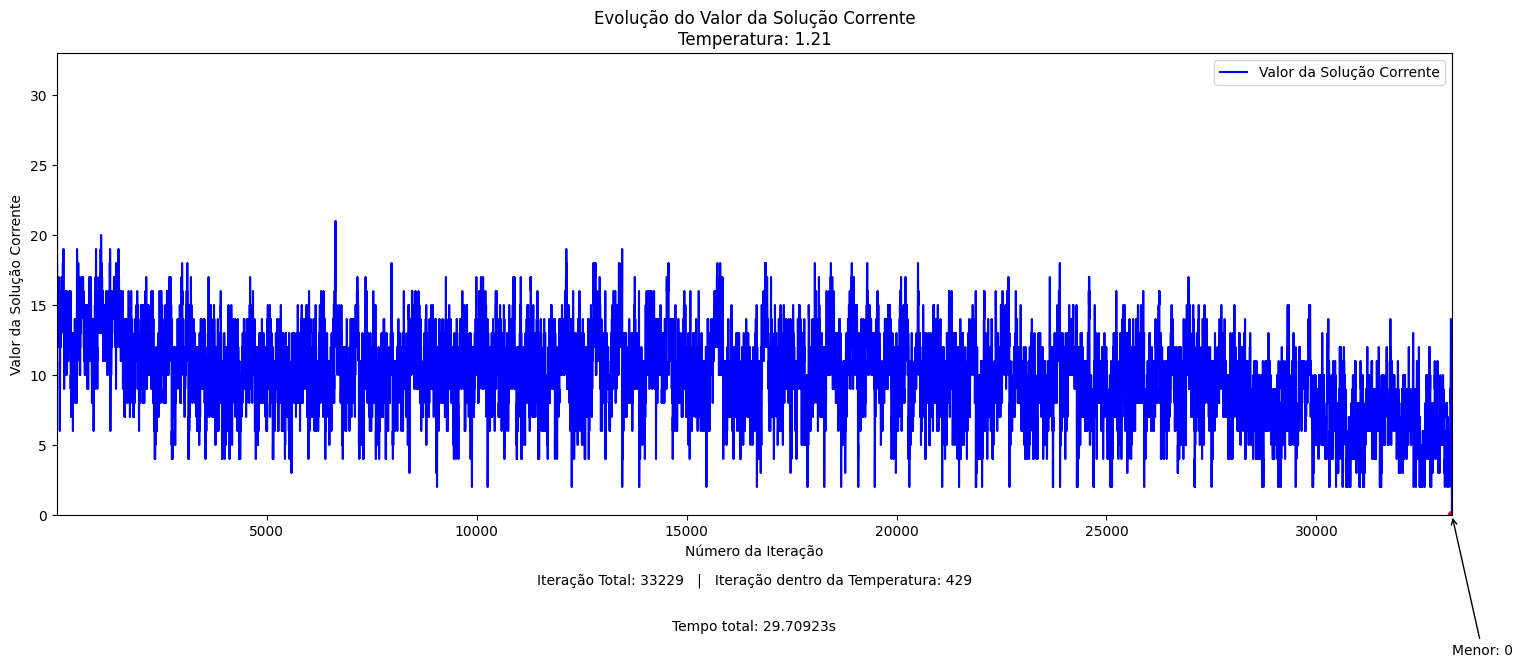

In [101]:
#@title Simulated Anneling for solving sudoku
#@title Simulated Annealing com grafico
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output

def sudokuSA_enhanced_graf(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0

    curr_state = solver.copy()

    freezing_temperature = 0.5

    fitness_values = []  # Lista para armazenar os valores de fitness em cada iteração

    fig, ax = plt.subplots(figsize=(18, 6))  # Aumenta o tamanho do gráfico
    ax.set_xlabel('Número da Iteração')
    ax.set_ylabel('Valor da Solução Corrente')
    ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')

    iteration_text = ax.text(0.5, -0.15, '', transform=ax.transAxes, ha='center')
    time_text = ax.text(0.5, -0.25, '', transform=ax.transAxes, ha= 'center')

    start_time = time.time()

    iter_sem_melhora = 0

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            if iter_sem_melhora > SA_MAX/2:
                iter_sem_melhora = 0
                temperature *= cooling_rate
                curr_state = best_state.copy()
                print(f'Atingiu plato, temperatura: {temperature:.2f}')
            iterT += 1

            iter_sem_melhora += 1

            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    iter_sem_melhora = 0
                    best_state = curr_state.copy()
                    b_fit = c_fit


                    # draw_sudoku(best_state, True)
            elif np.random.random() < np.exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            fitness_values.append(c_fit)  # Adiciona o valor de fitness na lista
            if c_fit == 0:
                print(f'c-fit == 0')
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature:.2f}, Melhor fitness: {b_fit}')
        ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')
        iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')

    end_time = time.time()
    total_time = end_time - start_time
    time_values = [total_time] * len(fitness_values)

    time_text.set_text(f'Tempo total: {total_time:.5f}s')
    SA_MAX = len(fitness_values)  # Update SA_MAX to the actual number of iterations

    iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')
    # Encontra o índice do menor valor na iteração corrente
    min_index = np.argmin(fitness_values)

    ax.plot(range(1, SA_MAX + 1), fitness_values, 'b-', label='Valor da Solução Corrente')  # Plota o gráfico atualizado
    # ax.plot(range(1, SA_MAX + 1), time_values, 'r-', label='Tempo (s)')  # Plota o tempo
    ax.set_xlim([1, SA_MAX])  # Define os limites do eixo x
    ax.set_ylim([0, max(fitness_values) + 10])  # Define os limites do eixo y

    # Plota o ponto fixo no menor valor da iteração corrente
    ax.scatter(min_index + 1, fitness_values[min_index], color='r')

    # Anota o valor do menor elemento no gráfico
    ax.annotate(f'Menor: {fitness_values[min_index]}', xy=(min_index + 1, fitness_values[min_index]),
                xytext=(min_index + 1, fitness_values[min_index] - 10),
                arrowprops=dict(facecolor='black', arrowstyle='->'))

    ax.legend()

    plt.show()
    plt.close(fig)  # Fecha a figura
    return best_state



nome_arquivo = "./instancias/dificil (0.9)/instancia0.txt"
puzzle = read_file(nome_arquivo)


SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

solver = SudokuSolver(3,3,puzzle)
# draw_sudoku(solver)
solver.greedy_solution()
solver = sudokuSA_enhanced_graf(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
# draw_sudoku(solver)


### Simulated Annealing que gera grafico do andamento da solucao

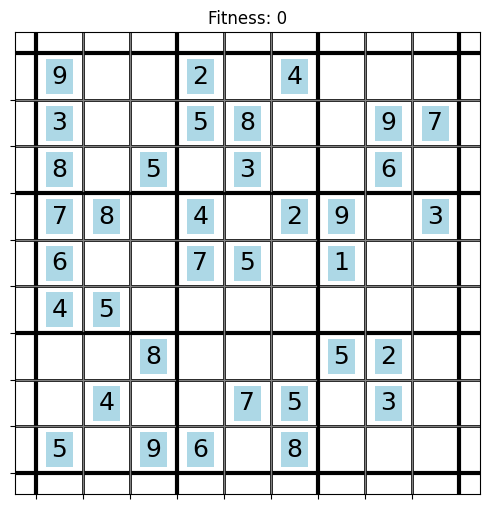

Temperature: 570.00
Temperature: 541.50
c-fit == 0


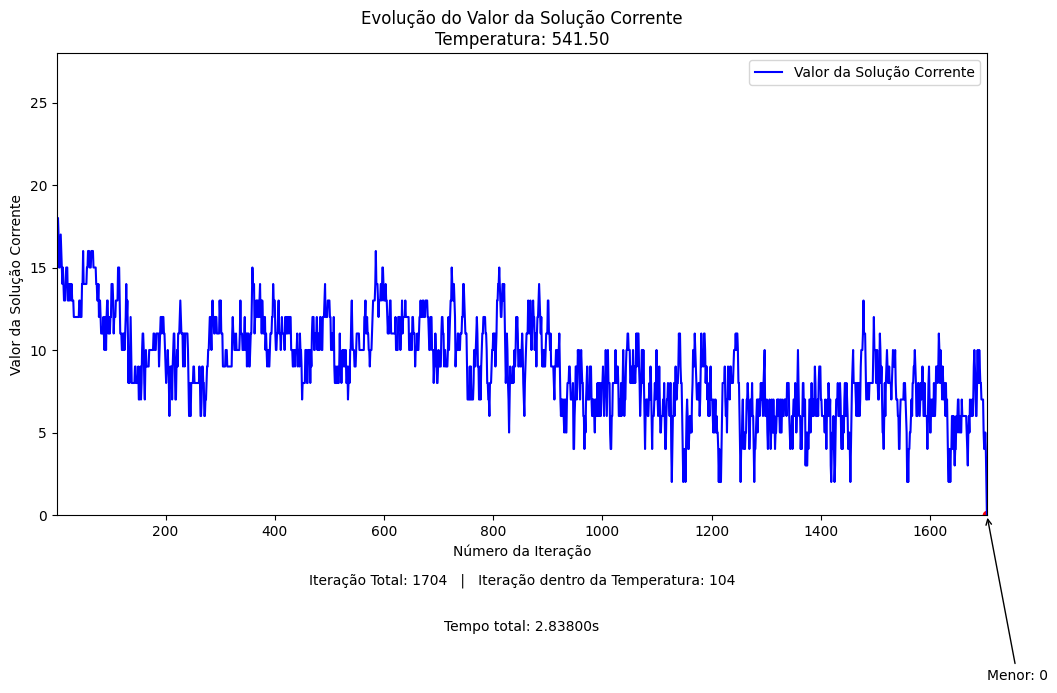

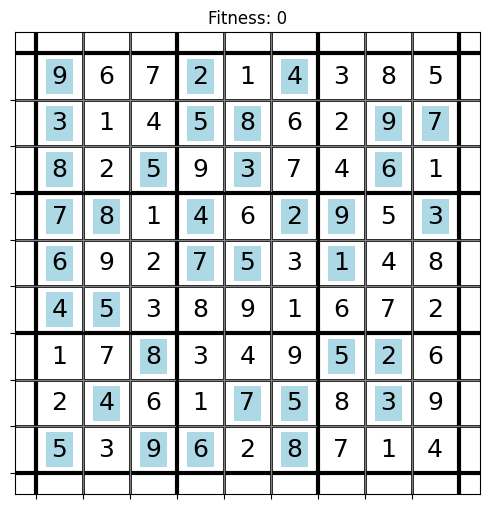

In [ ]:
#@title Simulated Annealing com grafico
import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output

def sudokuSA_graf(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature

    curr_state = solver.copy()

    freezing_temperature = 0.5

    fitness_values = []  # Lista para armazenar os valores de fitness em cada iteração
    time_values = []  # Lista para armazenar o tempo em cada iteração

    fig, ax = plt.subplots(figsize=(12, 6))  # Aumenta o tamanho do gráfico
    ax.set_xlabel('Número da Iteração')
    ax.set_ylabel('Valor da Solução Corrente')
    ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')

    iteration_text = ax.text(0.5, -0.15, '', transform=ax.transAxes, ha='center')
    time_text = ax.text(0.5, -0.25, '', transform=ax.transAxes, ha= 'center')

    start_time = time.time()

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            iterT += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    # draw_sudoku(best_state, True)
            elif np.random.random() < np.exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            fitness_values.append(c_fit)  # Adiciona o valor de fitness na lista
            if c_fit == 0:
                print(f'c-fit == 0')
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature:.2f}')
        ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')
        iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')

    end_time = time.time()
    total_time = end_time - start_time
    time_values = [total_time] * len(fitness_values)

    time_text.set_text(f'Tempo total: {total_time:.5f}s')
    SA_MAX = len(fitness_values)  # Update SA_MAX to the actual number of iterations

    iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')
    # Encontra o índice do menor valor na iteração corrente
    min_index = np.argmin(fitness_values)

    ax.plot(range(1, SA_MAX + 1), fitness_values, 'b-', label='Valor da Solução Corrente')  # Plota o gráfico atualizado
    # ax.plot(range(1, SA_MAX + 1), time_values, 'r-', label='Tempo (s)')  # Plota o tempo
    ax.set_xlim([1, SA_MAX])  # Define os limites do eixo x
    ax.set_ylim([0, max(fitness_values) + 10])  # Define os limites do eixo y

    # Plota o ponto fixo no menor valor da iteração corrente
    ax.scatter(min_index + 1, fitness_values[min_index], color='r')

    # Anota o valor do menor elemento no gráfico
    ax.annotate(f'Menor: {fitness_values[min_index]}', xy=(min_index + 1, fitness_values[min_index]),
                xytext=(min_index + 1, fitness_values[min_index] - 10),
                arrowprops=dict(facecolor='black', arrowstyle='->'))

    ax.legend()

    plt.show()
    plt.close(fig)  # Fecha a figura
    return best_state

nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)


SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

{'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
solver = SudokuSolver(3,3,puzzle)
draw_sudoku(solver)
solver.greedy_solution()
solver = sudokuSA_graf(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
draw_sudoku(solver)


#### Simulated Annealing que gera video do andamento da solucao

In [11]:
#@title video
import random
from math import exp
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def draw_sudoku_for_video(best: SudokuSolver = None, curr: SudokuSolver = None, iterT = 0):
    matrix1 = best.board
    matrix2 = curr.board

    fig = plt.figure(figsize=(12, 6))

    ax1 = plt.subplot(1, 2, 1)
    ax1.set_xticks(np.arange(0, 9, 1))
    ax1.set_yticks(np.arange(0, 9, 1))
    ax1.set_xticklabels([])
    ax1.set_yticklabels([])
    ax1.grid(color='black', linestyle='-', linewidth=2)
    if best.fit() == 0:
        ax1.set_title(f'Melhor Solução\nFitness: {best.fit()}\nIteração: {iterT} - Solução Encontrada')
    else:
        ax1.set_title(f'Melhor Solução\nFitness: {best.fit()}')

    for i in range(9):
        for j in range(9):
            value = matrix1[i][j]
            if value != 0:
                if value is None:
                    ax1.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if best.fixed_cells[i][j]:
                        ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if best.have_duplicates_row_col((i, j), matrix1[i][j], matrix1) > 2:
                            ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                    bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax1.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax1.axhline(i, color='black', linewidth=3)
        ax1.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax1.axhline(i, color='black', linewidth=2)
            ax1.axvline(i, color='black', linewidth=2)
        else:
            ax1.axhline(i, color='gray', linewidth=1)
            ax1.axvline(i, color='gray', linewidth=1)

    ax2 = plt.subplot(1, 2, 2)
    ax2.set_xticks(np.arange(0, 9, 1))
    ax2.set_yticks(np.arange(0, 9, 1))
    ax2.set_xticklabels([])
    ax2.set_yticklabels([])
    ax2.grid(color='black', linestyle='-', linewidth=2)
    ax2.set_title(f'Solução Corrente\nFitness: {curr.fit()}  iterT: {iterT}')

    for i in range(9):
        for j in range(9):
            value = matrix2[i][j]
            if value != 0:
                if value is None:
                    ax2.text(j + 0.5, 8 - i + 0.5, ' ', va='center', ha='center', fontsize=18)
                else:
                    if curr.fixed_cells[i][j]:
                        ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                color='black', bbox=dict(facecolor='lightblue', edgecolor='none'))
                    else:
                        if curr.have_duplicates_row_col((i, j), matrix2[i][j], matrix2) > 2:
                            ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18,
                                    bbox=dict(facecolor='red', edgecolor='none'))
                        else:
                            ax2.text(j + 0.5, 8 - i + 0.5, str(value), va='center', ha='center', fontsize=18)

    for i in range(0, 10, 3):
        ax2.axhline(i, color='black', linewidth=3)
        ax2.axvline(i, color='black', linewidth=3)

    for i in range(1, 9):
        if i % 3 == 0:
            ax2.axhline(i, color='black', linewidth=2)
            ax2.axvline(i, color='black', linewidth=2)
        else:
            ax2.axhline(i, color='gray', linewidth=1)
            ax2.axvline(i, color='gray', linewidth=1)

    plt.tight_layout()

    return fig



def sudokuSA_video(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0

    curr_state = solver.copy()

    freezing_temperature = 0.5

    if not os.path.exists('sudoku_video'):
        os.mkdir('sudoku_video')

    fps = 15

    video_output = cv2.VideoWriter('./sudoku_video/sudoku_video_fast.mp4', cv2.VideoWriter_fourcc(*'mp4v'), fps, (1200, 600))

    iter_sem_melhora = 0

    fig = None

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            if iter_sem_melhora > 100:
                print(f'Bateu em um platô de {iter_sem_melhora} iterações sem melhora, reduzindo a temperatura')
                break
            iterT += 1
            iter_sem_melhora += 1

            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                # print(f'Tava ha {iter_sem_melhora} iterações sem melhora, mas melhorou agora')
                if c_fit < b_fit:
                    iter_sem_melhora = 0    
                    best_state = curr_state.copy()
                    b_fit = c_fit
                fig = draw_sudoku_for_video(best= best_state, curr= curr_state, iterT= iterT)
                fig.canvas.draw()
                video_output.write(cv2.cvtColor(np.array(fig.canvas.renderer.buffer_rgba()), cv2.COLOR_RGBA2BGR))
                plt.close()
            elif random.random() < exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                iter_sem_melhora = 0

            

            if c_fit == 0:
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature}')

    # Manter o ultimo frame por mais tempo
    for i in range(fps * 5):
        video_output.write(cv2.cvtColor(np.array(fig.canvas.renderer.buffer_rgba()), cv2.COLOR_RGBA2BGR))
    video_output.release()

    return best_state

nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)


SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

# {'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
solver = SudokuSolver(3,3,puzzle)
solver.greedy_solution()
# draw_sudoku(solver)
sudokuSA_video(solver, SA_MAX, TEMPERATURE, COOLING_RATE)


Temperature: 570.0
Temperature: 541.5
Temperature: 514.425
Temperature: 488.70374999999996


#### Simulated Annealing gerar video do grafico do valor da solucao corrente

In [ ]:
#@title video


import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output
import cv2

import matplotlib.pyplot as plt
import numpy as np
import time
from IPython.display import display, clear_output
import cv2

def sudokuSA_graf_video(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature

    curr_state = solver.copy()

    freezing_temperature = 0.5

    fitness_values = []  # Lista para armazenar os valores de fitness em cada iteração
    time_values = []  # Lista para armazenar o tempo em cada iteração

    fig, ax = plt.subplots(figsize=(18, 6))  # Aumenta o tamanho do gráfico
    ax.set_xlabel('Número da Iteração')
    ax.set_ylabel('Valor da Solução Corrente')
    ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')

    iteration_text = ax.text(0.5, -0.15, '', transform=ax.transAxes, ha='center')
    time_text = ax.text(0.5, -0.25, '', transform=ax.transAxes, ha= 'center')

    start_time = time.time()

    # Parâmetros do vídeo
    video_filename = 'sudoku_sa_graph_2.mp4'
    fps = 10  # Frames por segundo
    frame_size = (1200, 800)  # Tamanho do frame

    # Cria o objeto VideoWriter
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video_out = cv2.VideoWriter(video_filename, fourcc, fps, frame_size)

    img = np.zeros((800, 1200, 3), np.uint8)

    iter_sem_melhora = 0

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            if iter_sem_melhora > 100:
                iter_sem_melhora = 0
                print(f'Bateu em um platô de {iter_sem_melhora} iterações sem melhora, reduzindo a temperatura')
                # curr_state = best_state.copy()
                break
            iterT += 1
            iter_sem_melhora += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit

                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    print(f'Iteração: {iterT} | Valor da Solução: {b_fit}')
                    iter_sem_melhora = 0
                    # draw_sudoku(best_state, True)
            elif np.random.random() < np.exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            fitness_values.append(c_fit)  # Adiciona o valor de fitness na lista
            ax.set_title(f'Evolução do Valor da Solução Corrente\nTemperatura: {temperature:.2f}')
            iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')

            # Atualiza o gráfico
            ax.plot(range(1, len(fitness_values) + 1), fitness_values, 'b-', label='Valor da Solução Corrente')

            # Converte o gráfico em uma imagem
            fig.canvas.draw()
            img = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
            img = img.reshape(fig.canvas.get_width_height()[::-1] + (3,))
            # converter RGB para BGR
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

            # Redimensiona a imagem para o tamanho do frame
            img = cv2.resize(img, frame_size)

            # display(fig)  # Mostra o gráfico
            # clear_output(wait=True)  # Limpa o output do Jupyter Notebook

            # Adiciona o frame ao vídeo
            video_out.write(img)
            if c_fit == 0:
                print(f'c-fit == 0')
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature:.2f}')
        

    end_time = time.time()
    total_time = end_time - start_time
    time_values = [total_time] * len(fitness_values)

    # Deixa a imagem final por 5 segundos
    for i in range(5 * fps):
        video_out.write(img)

    time_text.set_text(f'Tempo total: {total_time:.5f}s')
    SA_MAX = len(fitness_values)  # Update SA_MAX to the actual number of iterations

    iteration_text.set_text(f'Iteração Total: {iterT}   |   Iteração dentro da Temperatura: {i+1}')
    # Encontra o índice do menor valor na iteração corrente
    min_index = np.argmin(fitness_values)

    ax.plot(range(1, SA_MAX + 1), fitness_values, 'b-', label='Valor da Solução Corrente')  # Plota o gráfico atualizado
    ax.set_xlim([1, SA_MAX])  # Define os limites do eixo x
    ax.set_ylim([0, max(fitness_values) + 10])  # Define os limites do eixo y

    # Plota o ponto fixo no menor valor da iteração corrente
    ax.scatter(min_index + 1, fitness_values[min_index], color='r')

    # Anota o valor do menor elemento no gráfico
    ax.annotate(f'Menor: {fitness_values[min_index]}', xy=(min_index + 1, fitness_values[min_index]),
                xytext=(min_index + 1, fitness_values[min_index] - 10),
                arrowprops=dict(facecolor='black', arrowstyle='->'))

    ax.legend()

    plt.show()
    plt.close(fig)  # Fecha a figura

    # Fecha o objeto VideoWriter
    video_out.release()

    return best_state




nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)


SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

# {'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
solver = SudokuSolver(3,3,puzzle)
solver.greedy_solution()
# draw_sudoku(solver)
solver=sudokuSA_graf_video(solver, SA_MAX, TEMPERATURE, COOLING_RATE)
draw_sudoku(solver)


### Execucao de apenas 1 instancia

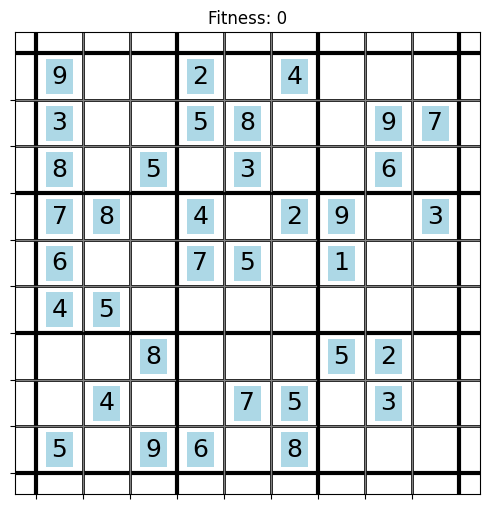

Fitness: 45
[9, 1, 4, 2, 9, 4, 4, 2, 3]
[3, 2, 6, 5, 8, 1, 5, 9, 7]
[8, 7, 5, 6, 3, 7, 1, 6, 8]
[7, 8, 3, 4, 1, 2, 9, 8, 3]
[6, 1, 2, 7, 5, 6, 1, 2, 7]
[4, 5, 9, 3, 8, 9, 6, 4, 5]
[7, 2, 8, 1, 2, 4, 5, 2, 8]
[1, 4, 6, 9, 7, 5, 4, 3, 1]
[5, 3, 9, 6, 3, 8, 9, 6, 7]


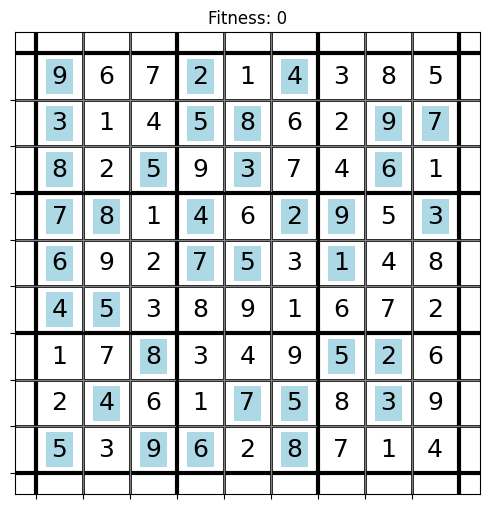

In [7]:
#@title Rodar apenas 1 instancia
nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)


SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

# {'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
solver = SudokuSolver(3,3,puzzle)
draw_sudoku(solver)
solver.random_solution()
solver.show()
solver = sudokuSA(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
draw_sudoku(solver)

## Algoritmo Genetico

Parametros:
Tamanho da populacao|Numero maximo de geracoes|Taxa de mutacao|Numero de individuos selecionados para reproducao|Geracoes sem melhora|A cada quantas geracoes deve resetar a populacao
---|---|---|---|---|---
200|1200|0.25|$Tamanho Da Populacao/2$|50|150

* Cada par de individuos geram dois filhos
* Taxa de selecao para reproducao é metade da populacao para sempre gerar uma nova geracao com o mesmo tamanho da populacao anterior


In [23]:
def sudokuSA_for_GA(solver: SudokuSolver, SA_MAX=800, temperature=600, cooling_rate=0.95):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature
    curr_state = solver.copy()

    freezing_temperature = 0.5

    iter_sem_melhora = 0

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            if iter_sem_melhora > SA_MAX/2:
                iter_sem_melhora = 0
                temperature *= cooling_rate
                curr_state = best_state.copy()
                # print(f'Atingiu plato, temperatura: {temperature:.2f}')
            iterT += 1
            iter_sem_melhora += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                # print(f'c-fit: {curr_state.fit()} v-fit: {j_fit}')
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    iter_sem_melhora = 0
                    # draw_sudoku(best_state, True)
            elif np.random.random() < np.exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            # print(f'c-fit: {c_fit}')
            if c_fit == 0:
                # print(f'c-fit == 0')
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate
        print(f'Temperature: {temperature:.2f}, Best fit: {b_fit}')

    return best_state, iterT

Generation: 0
Best fit: 12
Generation: 1
Best fit: 12
Generation: 2
Best fit: 10
Generation: 3
Best fit: 10
Generation: 4
Best fit: 10
Generation: 5
Best fit: 10
Generation: 6
Best fit: 10
Generation: 7
Best fit: 10
Generation: 8
Best fit: 10
Generation: 9
Best fit: 10
Generation: 10
Best fit: 8
Generation: 11
Best fit: 8
Generation: 12
Best fit: 8
Generation: 13
Best fit: 8
Generation: 14
Best fit: 8
Generation: 15
Best fit: 8
Generation: 16
Best fit: 6
Generation: 17
Best fit: 6
Generation: 18
Best fit: 6
Generation: 19
Best fit: 6
Generation: 20
Best fit: 6
Generation: 21
Best fit: 6
Generation: 22
Best fit: 6
Generation: 23
Best fit: 5
Generation: 24
Best fit: 5
Generation: 25
Best fit: 5
Generation: 26
Best fit: 5
Generation: 27
Best fit: 4
Generation: 28
Best fit: 4
Generation: 29
Best fit: 4
Generation: 30
Best fit: 4
Generation: 31
Best fit: 4
Generation: 32
Best fit: 4
Generation: 33
Best fit: 4
Generation: 34
Best fit: 4
Generation: 35
Best fit: 4
Generation: 36
Best fit: 4
G

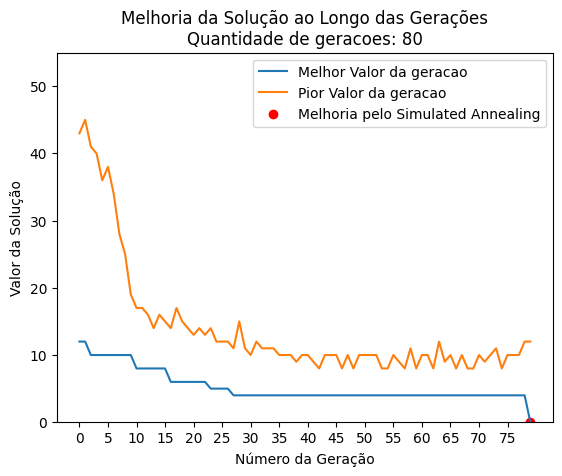

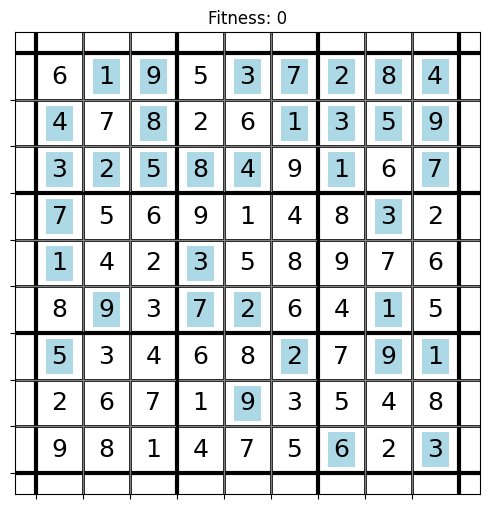

In [50]:
import math
from typing import List
import random
import numpy as np

class SudokuGA(SudokuSolver):
    MUTATION_RATE = 0.33
    POPULATION_SIZE = 400
    MAX_GENERATIONS = 1200
    GENERATIONS_WITHOUT_IMPROVEMENT = 50
    RESTART_POPULATION_WHEN_REACH = 150

    SA_MAX= 800
    TEMPERATURE= 600
    COOLING_RATE= 0.95

    def __init__(self, n, m, puzzle):
        super().__init__(n, m, puzzle)
        self.population = []

    def generate_initial_population(self, size=POPULATION_SIZE) -> None:
        '''
        size: Tamanho da população inicial
        '''
        pop = []
        for i in range(size - 1):
            ind = self.random_solution(change_self=False)
            ind = SudokuSolver(self.sub_lines, self.sub_cols, ind)
            ind.fixed_cells = self.fixed_cells
            pop.append(ind)

        ind = self.greedy_solution(change_self=False)
        ind = SudokuSolver(self.sub_lines, self.sub_cols, ind)
        ind.fixed_cells = self.fixed_cells
        pop.append(ind)

        self.population = pop.copy()
        self.population.sort(key= lambda x: x.fit())
        # print("[*] Populacao inicial gerada")
        # print([self.fit(i) for i in self.population])
    
    def fit_ind(self, individual):
        return individual.fit()
    
    def selection(self, selection_rate=POPULATION_SIZE/2) -> List[SudokuSolver]:
        '''
        selection_rate: Seleciona k individuos da população atual
        '''
        probabilities = [math.exp(-i.fit()) for i in self.population]
        n_population = [i for i in range(len(self.population))]
        normalized_probabilities = [i/sum(probabilities) for i in probabilities]
        selected_index = []
        #? Escolhe os indices dos individuos com base nos pesos
        for i in range(int(selection_rate)):
            # selected: indice do individuo selecionado
            selected = random.choices(n_population, normalized_probabilities, k=1)[0]
            index = n_population.index(selected)
            # adiciona o indice ao array de indices
            selected_index.append(selected)
            #* Remove o individuo selecionado para que não seja selecionado novamente
            # print(f'Preciso remover o valor: {selected}')
            
            del n_population[index]
            del normalized_probabilities[index]

        selected = [self.population[i] for i in selected_index]
        # print("[*] Individuos selecionados")
        return selected
    
    def next_generation(self, selected_individuals) -> List[SudokuSolver]:
            next_generation = selected_individuals.copy()
            children = []
            # Realizar cruzamento (recombinação) entre os indivíduos selecionados
            for i in range(0, len(selected_individuals), 2):
                parent1 = selected_individuals[i]
                parent2 = selected_individuals[i+1]

                child1, child2 = self.crossover(parent1, parent2)

                children.append(child1)
                children.append(child2)

            # Aplicar mutação nos indivíduos da próxima geração
            for i in range(len(children)):
                mutated_individual = self.mutation(children[i])
                next_generation.append(mutated_individual)
            # print("[*] Nova geração gerada")
            return next_generation
        
    
    def crossover(self, parent1: SudokuSolver, parent2: SudokuSolver):

        croosover_point = random.randint(1, parent1.lines - 1)
        child1 = [[0] * parent1.lines for i in range(parent1.lines)]
        child2 = [[0] * parent1.lines for i in range(parent1.lines)]

        grid_cols = parent1.sub_cols
        grid_line = parent1.sub_lines

        for k in range(parent1.sub_lines * parent1.sub_cols):

            start_line = (k // grid_cols) * grid_line
            start_col = (k % grid_cols) * grid_cols
            if k < croosover_point:

                for i in range(grid_line):
                    for j in range(grid_cols):
                        child1[start_line + i][start_col + j] = parent1.board[start_line + i][start_col + j]
                        child2[start_line + i][start_col + j] = parent2.board[start_line + i][start_col + j]
            else:
                for i in range(grid_line):
                    for j in range(grid_cols):
                        child2[start_line + i][start_col + j] = parent1.board[start_line + i][start_col + j]
                        child1[start_line + i][start_col + j] = parent2.board[start_line + i][start_col + j]

        child1 = SudokuSolver(parent1.sub_lines, parent1.sub_cols, child1)
        child2 = SudokuSolver(parent1.sub_lines, parent1.sub_cols, child2)
        child1.fixed_cells = parent1.fixed_cells
        child2.fixed_cells = self.fixed_cells
        # print("[*] Cruzamento realizado")
        return child1, child2

    def mutation(self, individual: SudokuSolver):
        r = np.random.random()
        if r < self.MUTATION_RATE:
            grids = individual.grids()
            #grid recebe um filtro para que as celulas nao sejam as fixas
            grid = random.choice(grids)
            grid_coords = set()
            for el in range(len(grid)):
                if self.fixed_cells[grid[el][1][0]][grid[el][1][1]] == False:
                    grid_coords.add(grid[el])

            if len(grid_coords) > 1:
                random_cell1 = random.choice(list(grid_coords))
                grid_coords.remove(random_cell1)
                random_cell2 = random.choice(list(grid_coords))

                # print(f'random_cell1: {random_cell1}, random_cell2: {random_cell2}')
                individual.board[random_cell1[1][0]][random_cell1[1][1]],individual.board[random_cell2[1][0]][random_cell2[1][1]] = individual.board[random_cell2[1][0]][random_cell2[1][1]], individual.board[random_cell1[1][0]][random_cell1[1][1]]
                # print(f"[*] Mutação realizada, {r} < {self.MUTATION_RATE}")
        else:
            # print(f"[*] Mutação não realizada, {r} > {self.MUTATION_RATE}")
            pass
        return individual
    
    def solve(self):
        self.generate_initial_population()
        generation_without_improvement = 0
        best_fit = self.population[0].fit()
        actual_generation = 0
        for i in range(self.MAX_GENERATIONS):
            print(f'Generation: {i}')
            # print(f'Tamanho da população: {len(self.population)}')
            selected = self.selection()
            # print(f'Tamanho da seleção: {len(selected)}')
            next_generation = self.next_generation(selected)
            # print(f'Tamanho da nova geração: {len(next_generation)}')
            self.population = next_generation.copy()
            # print(f'Tamanho da população: {len(self.population)}')
            self.population.sort(key= lambda x: x.fit())
            if self.population[0].fit() < best_fit:
                generation_without_improvement = 0
                best_fit = self.population[0].fit()
            else:
                generation_without_improvement += 1
            print(f'Best fit: {self.population[0].fit()}')

            if i % self.RESTART_POPULATION_WHEN_REACH == 0 and i != 0:
                print("Restart da população")
                best_ind = self.population[0].copy()
                self.generate_initial_population()
                #self.population[0] = best_ind
            if generation_without_improvement > self.GENERATIONS_WITHOUT_IMPROVEMENT:
                # usar o simulated annealing
                print("Simulated Annealing")
                sudokuSA, iterT = sudokuSA_for_GA(self.population[0], SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
                self.population[0] = sudokuSA
                # print(f'Best fit depois do SA: {self.population[0].fit()}')
                generation_without_improvement = 0
            if self.population[0].fit() == 0:
                return self.population[0], actual_generation
            actual_generation += 1
        return self.population[0], actual_generation
    
    def solve_graf(self):
        self.generate_initial_population()
        generation_without_improvement = 0
        best_fit = self.population[0].fit()
        actual_generation = 0
        fitness_values = []  # Lista para armazenar os valores de fitness
        worst_fitness_values = []  # Lista para armazenar os piores valores de fitness
        sa_generations = []  # Lista para armazenar as gerações com aplicação do Simulated Annealing

        for i in range(self.MAX_GENERATIONS):
            print(f'Generation: {i}')
            selected = self.selection()
            next_generation = self.next_generation(selected)
            self.population = next_generation.copy()
            self.population.sort(key=lambda x: x.fit())
            if self.population[0].fit() < best_fit:
                generation_without_improvement = 0
                best_fit = self.population[0].fit()
            else:
                generation_without_improvement += 1
            print(f'Best fit: {self.population[0].fit()}')

            fitness_values.append(self.population[0].fit())  # Adicionar valor de fitness à lista
            worst_fitness_values.append(self.population[-1].fit())  # Adicionar valor de fitness à lista

            if i % self.RESTART_POPULATION_WHEN_REACH == 0 and i != 0:
                print("Restart da população")
                best_ind = self.population[0].copy()
                self.generate_initial_population()

            if generation_without_improvement > self.GENERATIONS_WITHOUT_IMPROVEMENT:
                print("Simulated Annealing")
                sudokuSA, iterT = sudokuSA_for_GA(self.population[0], SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
                self.population[0] = sudokuSA
                generation_without_improvement = 0
                fitness_values.append(self.population[0].fit())  # Adicionar valor de fitness à lista
                worst_fitness_values.append(self.population[-1].fit())  # Adicionar valor de fitness à lista
                actual_generation += 1
                sa_generations.append(actual_generation)  # Adicionar geração com SA à lista

            actual_generation += 1
            if self.population[0].fit() == 0:
                break

        # Plotar o gráfico
        plt.plot(range(actual_generation), fitness_values, label='Melhor Valor da geracao')
        plt.plot(range(actual_generation), worst_fitness_values, label='Pior Valor da geracao')
        plt.scatter(sa_generations, [fitness_values[actual_generation - 1] for i in sa_generations], color='red', label='Melhoria pelo Simulated Annealing')
        plt.xlabel('Número da Geração')
        plt.ylabel('Valor da Solução')
        plt.title(f'Melhoria da Solução ao Longo das Gerações\nQuantidade de geracoes: {actual_generation}')
        plt.legend()  # Adicionar legenda ao gráfico
        plt.xticks(range(0, actual_generation, 5))
        plt.ylim([0, max(worst_fitness_values) + 10])
        plt.show()

        return self.population[0], actual_generation


    

# instances = [ 1,  5,  6,  7,  9, 10, 11, 25, 28, 30, 32, 37, 38, 39, 43, 44, 45, 46]


nome_arquivo = f"./instancias/facil (0.3)/instancia45.txt"
puzzle = read_file(nome_arquivo)


sudokuGA = SudokuGA(3,3,puzzle)
solved, generations = sudokuGA.solve_graf()
draw_sudoku(solved)


## Execucao do Simulated Annealing para obter resultados

### Execucao de 300 instancias faceis com a vizinhanca melhorada

In [114]:


import time

SA_MAX= 800
TEMPERATURE= 600
COOLING_RATE= 0.95

time_values = []
iterations_values = []
fitness_values = []

max_instances = 50

for i in range(max_instances):
    print(f'Instância {i}')
    nome_arquivo = f"./instancias/dificil (0.9)/instancia{i}.txt"
    puzzle = read_file(nome_arquivo)
    solver = SudokuSolver(3,3,puzzle)
    # draw_sudoku(solver)
    solver.greedy_solution()

    start = time.time()
    solver, iterations = sudokuSA_enhanced(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
    end = time.time()
    
    iterations_values.append(iterations)
    time_values.append(end-start)
    fitness_values.append(solver.fit())
    # draw_sudoku(solver)

filename = 'Metricas.txt'
with open(filename, 'a') as f:
    f.write(f'{max_instances} - Instancias de dificuldade dificil (0.9)\n')
    f.write(f'Média de iteracoes: {np.mean(iterations_values)}\n')
    f.write(f'Média de tempo: {np.mean(time_values):.2f}s\n')
    f.write(f'Maior iteracao: {np.max(iterations_values)}\n')
    f.write(f'Menor iteracao: {np.min(iterations_values)}\n')
    f.write(f'Maior tempo: {np.max(time_values):.2f}s\n')
    f.write(f'Menor tempo: {np.min(time_values):.2f}s\n')
    f.write(f'Indice das instancias que nao foram resolvidas: {np.where(np.array(fitness_values) != 0)}\n')
    f.write(f'Maior fitness: {np.max(fitness_values)}\n')

    f.write('\n\n\n')

    print(f'Média de iterações: {np.mean(iterations_values)}')
    print(f'Média de tempo: {np.mean(time_values):.2f}s')
    print(f'Maior iteração: {np.max(iterations_values)}')
    print(f'Menor iteração: {np.min(iterations_values)}')
    print(f'Maior tempo: {np.max(time_values):.2f}s')
    print(f'Menor tempo: {np.min(time_values):.2f}s')
    print(f'Indice das instancias que nao foram resolvidas: {np.where(np.array(fitness_values) != 0)}')
    print(f'Maior fitness: {np.max(fitness_values)}')





Instância 0
Instância 1
Instância 2
Instância 3
Instância 4
Instância 5
Instância 6
Instância 7
Instância 8
Instância 9
Instância 10
Instância 11
Instância 12
Instância 13
Instância 14
Instância 15
Instância 16
Instância 17
Instância 18
Instância 19
Instância 20
Instância 21
Instância 22
Instância 23
Instância 24
Instância 25
Instância 26
Instância 27
Instância 28
Instância 29
Instância 30
Instância 31
Instância 32
Instância 33
Instância 34
Instância 35
Instância 36
Instância 37
Instância 38
Instância 39
Instância 40
Instância 41
Instância 42
Instância 43
Instância 44
Instância 45
Instância 46
Instância 47
Instância 48
Instância 49
Média de iterações: 28047.96
Média de tempo: 26.11s
Maior iteração: 38400
Menor iteração: 2520
Maior tempo: 38.87s
Menor tempo: 2.08s
Indice das instancias que nao foram resolvidas: (array([ 5,  6,  8,  9, 10, 11, 16, 18, 27, 34, 35, 36, 45], dtype=int64),)
Maior fitness: 2


In [27]:


import time

max_instances = 50
levels = [ 'facil (0.3)', 'medio (0.6)', 'dificil (0.9)']

all_time_values = []
all_generations_values = []
all_fitness_values = []

for level in levels:
    time_values = []
    generations_values = []
    fitness_values = []
    for i in range(max_instances):
        print(f'Instância {i} - {level}')
        nome_arquivo = f"./instancias/{level}/instancia{i}.txt"
        puzzle = read_file(nome_arquivo)


        sudokuGA = SudokuGA(3,3,puzzle)

        start = time.time()
        solver, gens = sudokuGA.solve()
        end = time.time()
        
        generations_values.append(gens)
        time_values.append(end-start)
        fitness_values.append(solver.fit())
        # draw_sudoku(solver)

    all_generations_values.append(generations_values)
    all_time_values.append(time_values)
    all_fitness_values.append(fitness_values)

    filename = 'Metricas.txt'
    with open(filename, 'a') as f:
        f.write(f'{max_instances} - Instancias de dificuldade {level}\n')
        f.write(f'Média de geracoes: {np.mean(generations_values)}\n')
        f.write(f'Média de tempo: {np.mean(time_values):.2f}s\n')
        f.write(f'Maior geracao: {np.max(generations_values)}\n')
        f.write(f'Menor geracao: {np.min(generations_values)}\n')
        f.write(f'Maior tempo: {np.max(time_values):.2f}s\n')
        f.write(f'Menor tempo: {np.min(time_values):.2f}s\n')
        f.write(f'Indice das instancias que nao foram resolvidas: {np.where(np.array(fitness_values) != 0)}\n')
        f.write(f'Maior fitness: {np.max(fitness_values)}\n')

        f.write('\n\n\n')

        print(f'Média de iterações: {np.mean(iterations_values)}')
        print(f'Média de tempo: {np.mean(time_values):.2f}s')
        print(f'Maior iteração: {np.max(iterations_values)}')
        print(f'Menor iteração: {np.min(iterations_values)}')
        print(f'Maior tempo: {np.max(time_values):.2f}s')
        print(f'Menor tempo: {np.min(time_values):.2f}s')
        print(f'Indice das instancias que nao foram resolvidas: {np.where(np.array(fitness_values) != 0)}')
        print(f'Maior fitness: {np.max(fitness_values)}')





Instância 0 - facil (0.3)
Instância 1 - facil (0.3)
Instância 2 - facil (0.3)
Temperature: 541.50, Best fit: 4
Instância 3 - facil (0.3)


KeyboardInterrupt: 

In [ ]:
import time

with open('resultados_facil_greedy_4-single.txt', 'w') as f:
    for i in range(300):
        nome_arquivo = f"./instancias/facil (0.3)/instancia{i}.txt"
        puzzle = read_file(nome_arquivo)

        SA_MAX = 800
        TEMPERATURE = 600
        COOLING_RATE = 0.95

        solver = SudokuSolver(3, 3, puzzle)
        solver.random_solution()
        start = time.time()
        try:
            solver, final_fit = sudokuSA(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)
            end = time.time()
            f.write(f'{i} {final_fit} {end - start}\n')
            f.flush()  # Grava os dados imediatamente no arquivo
            print(f'{i} {final_fit} {end - start}')
        except Exception as e:
            print(f'Ocorreu um erro na iteração {i}: {str(e)}')


### Valores para instancias faceis

In [ ]:
import threading

class MyThread(threading.Thread):
    def __init__(self, instance_range, SA_MAX, TEMPERATURE, COOLING_RATE):
        threading.Thread.__init__(self)
        self.instance_range = instance_range
        self.SA_MAX = SA_MAX
        self.TEMPERATURE = TEMPERATURE
        self.COOLING_RATE = COOLING_RATE

        print(f'Thread {self.name} iniciada com as instâncias {instance_range}')


    def run(self):
        # Lógica da sua thread
        all_values = []
        for i in self.instance_range:
            print(f'Instância {i} iniciada pela thread {self.name}, faltam {self.instance_range.stop - i}')
            nome_arquivo = f"./instancias/dificil (0.9)/instancia{i}.txt"
            puzzle = read_file(nome_arquivo)

            solver = SudokuSolver(3, 3, puzzle)
            solver.random_solution()
            start = time.time()
            try:
                solver, final_fit = sudokuSA(solver, SA_MAX=self.SA_MAX, temperature=self.TEMPERATURE, cooling_rate=self.COOLING_RATE)
                end = time.time()
                with open('resultados_dificil_1_greedy.txt', 'a') as f:
                    f.write(f'{i} {final_fit} {end - start}\n')
                    f.flush()  # Grava os dados imediatamente no arquivo
                # print(f'{i} {final_fit} {end - start}\n')
                all_values.append((i, final_fit, end - start))
            except Exception as e:
                print(f'Ocorreu um erro na iteração {i}: {str(e)}')
                all_values.append((i, None, None))
        return all_values

In [ ]:
SA_MAX = 800
TEMPERATURE = 600
COOLING_RATE = 0.95

threads: List[MyThread] = []
instances_per_thread = 19
total_instances = 300

all_values = []

for i in range(16):
    start_instance = i * instances_per_thread
    end_instance = min((i + 1) * instances_per_thread, total_instances)
    instance_range = range(start_instance, end_instance)
    
    thread = MyThread(instance_range, SA_MAX, TEMPERATURE, COOLING_RATE)
    threads.append(thread)
    thread.start()


for thread in threads:
    thread.join()
    # all_values += thread.run()


## Busca de valores para os parametros

In [ ]:
#@title Tentando encontrar bons parametros
import matplotlib.pyplot as plt
nome_arquivo = "./instancias/facil (0.3)/instancia0.txt"
puzzle = read_file(nome_arquivo)

def search_parameters(puzzle, parameter_sets):
    results = []
    for params in parameter_sets:
        SA_MAX = params['SA_MAX']
        TEMPERATURE = params['TEMPERATURE']
        COOLING_RATE = params['COOLING_RATE']

        solver = SudokuSolver(3, 3, puzzle)
        solver.greedy_solution()
        solver = sudokuSA(solver, SA_MAX=SA_MAX, temperature=TEMPERATURE, cooling_rate=COOLING_RATE)

        result = solver.fit()  # Medida de qualidade da solução (pode ser adaptada ao seu caso)
        results.append(result)

    return results


def plot_results(parameter_sets, results):
    x = range(len(parameter_sets))

    plt.plot(x, results, 'o-')
    plt.xlabel('Conjunto de Parâmetros')
    plt.ylabel('Resultado')
    plt.title('Busca de Parâmetros')
    plt.xticks(x, [str(i) for i in range(len(parameter_sets))])  # Mostra o índice do conjunto como legenda
    plt.tight_layout()
    plt.show()


# Defina seus conjuntos de parâmetros para a busca
parameter_sets = [
    {'SA_MAX': 400, 'TEMPERATURE': 200, 'COOLING_RATE': 0.75},
    {'SA_MAX': 500, 'TEMPERATURE': 300, 'COOLING_RATE': 0.8},
    {'SA_MAX': 600, 'TEMPERATURE': 400, 'COOLING_RATE': 0.85},
    {'SA_MAX': 700, 'TEMPERATURE': 500, 'COOLING_RATE': 0.9},
    {'SA_MAX': 800, 'TEMPERATURE': 600, 'COOLING_RATE': 0.95},
    {'SA_MAX': 900, 'TEMPERATURE': 700, 'COOLING_RATE': 0.75},
    {'SA_MAX': 1000, 'TEMPERATURE': 800, 'COOLING_RATE': 0.8},
    {'SA_MAX': 1100, 'TEMPERATURE': 900, 'COOLING_RATE': 0.85},
    {'SA_MAX': 1200, 'TEMPERATURE': 1000, 'COOLING_RATE': 0.9},
    {'SA_MAX': 1300, 'TEMPERATURE': 1100, 'COOLING_RATE': 0.95},
    # Adicione mais conjuntos de parâmetros conforme necessário
]

# Realize a busca de parâmetros e obtenha os resultados
results = search_parameters(puzzle, parameter_sets)

# Plote os resultados
plot_results(parameter_sets, results)



# BACKUP

In [ ]:
#@title Simulated Anneling for solving sudoku
from copy import deepcopy
import random
from math import exp
from IPython.display import clear_output

def sudokuSA(solver: SudokuSolver, SA_MAX=2500, temperature=140, cooling_rate=0.80):
    best_state = solver.copy()
    b_fit = best_state.fit()
    iterT = 0
    temp = temperature

    curr_state = solver.copy()

    freezing_temperature = 0.5

    while temperature > freezing_temperature:
        for i in range(SA_MAX):
            iterT += 1
            v = curr_state.make_all_grids_neighboor_exchange()

            v_best = []
            v_best_fit = 100

            for j in v:
                j_fit = fitness(j)
                if j_fit < v_best_fit:
                    v_best = [row[:] for row in j]
                    v_best_fit = j_fit

            vn = SudokuSolver(3, 3, v_best)
            vn.fixed_cells = curr_state.fixed_cells

            c_fit = curr_state.fit()
            v_fit = vn.fit()

            if v_fit < c_fit:
                curr_state = vn.copy()
                c_fit = v_fit
                if c_fit < b_fit:
                    best_state = curr_state.copy()
                    b_fit = c_fit
                    # draw_sudoku(curr_state)
                    # clear_output(wait=True)
            elif random.random() < exp((curr_state.fit() - vn.fit()) / temperature) and c_fit != v_fit:
                curr_state = vn.copy()
                c_fit = v_fit

            if c_fit == 0:
                break
        if b_fit == 0:
            break
        temperature *= cooling_rate

    return best_state
